<a href="https://colab.research.google.com/github/PusunuruVenkat/ML_PRACTICAL/blob/main/exp10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA

from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering
from sklearn.cluster import DBSCAN

from sklearn.metrics import silhouette_score

from scipy.cluster.hierarchy import dendrogram, linkage

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("All libraries imported successfully!")

All libraries imported successfully!


In [3]:
df = pd.read_csv(
    "/content/drive/MyDrive/colab/placement_predict_50k_adjusted.csv"
)

print("=" * 70)
print("DATASET LOADED")
print("=" * 70)

print("Shape:", df.shape)
print("Number of students:", len(df))

df.head()

DATASET LOADED
Shape: (50000, 21)
Number of students: 50000


,Gender,City,CollegeTier,Stream,Specialisation,Hostel,HistoryOfBacklogs,CGPA,AttendancePercent,Internships,...,Workshops,Certifications,Publications,AptitudeTestScore,SoftSkillsRating,CodingTestScore,MockInterviewScore,ExtraCurricular,PlacementStatus,IsAnomaly
0,Female,Delhi,Tier3,IT,DataScience,Yes,Yes,6.63,68.3,2,...,0.0,1,0,62.3,6.57,40.6,65.7,No,0,0
1,Male,Chennai,Tier2,ECE,AI,Yes,No,6.40,71.0,1,...,0.0,2,0,44.0,5.86,40.3,51.8,No,0,0
2,Female,Hyderabad,Tier3,ECE,Networking,No,No,7.73,75.1,1,...,2.0,2,1,73.8,7.50,73.6,67.9,No,1,0
3,Female,Jaipur,Tier3,ECE,Embedded,No,No,9.73,99.2,4,...,5.0,6,2,100.0,9.41,98.7,NaN,No,1,0
4,Male,Ahmedabad,Tier3,Mechanical,DataScience,No,No,9.01,99.6,2,...,NaN,4,2,90.8,9.24,83.1,100.0,No,1,0


In [5]:
print("Dataset columns:")
print()

for i, col in enumerate(df.columns, 1):
    print(i, "->", col)

Dataset columns:

1 -> Gender
2 -> City
3 -> CollegeTier
4 -> Stream
5 -> Specialisation
6 -> Hostel
7 -> HistoryOfBacklogs
8 -> CGPA
9 -> AttendancePercent
10 -> Internships
11 -> Projects
12 -> Workshops
13 -> Certifications
14 -> Publications
15 -> AptitudeTestScore
16 -> SoftSkillsRating
17 -> CodingTestScore
18 -> MockInterviewScore
19 -> ExtraCurricular
20 -> PlacementStatus
21 -> IsAnomaly


In [6]:
NUMERIC_COLS = [
    "CGPA",
    "AttendancePercent",
    "Internships",
    "Projects",
    "Workshops",
    "Certifications",
    "Publications",
    "AptitudeTestScore",
    "SoftSkillsRating",
    "CodingTestScore",
    "MockInterviewScore",
]

CATEGORICAL_COLS = [
    "Gender",
    "City",
    "CollegeTier",
    "Stream",
    "Specialisation",
    "Hostel",
    "HistoryOfBacklogs",
    "ExtraCurricular",
]

print("Numeric columns:", len(NUMERIC_COLS))
print("Categorical columns:", len(CATEGORICAL_COLS))

Numeric columns: 11
Categorical columns: 8


In [7]:
# Handle missing numerical values
imputer = SimpleImputer(strategy="median")

num_df = pd.DataFrame(
    imputer.fit_transform(df[NUMERIC_COLS]),
    columns=NUMERIC_COLS,
    index=df.index
)

# Convert categorical variables into numerical dummy variables
cat_df = pd.get_dummies(
    df[CATEGORICAL_COLS],
    drop_first=True
)

# Combine numerical and categorical features
feature_df = pd.concat(
    [num_df, cat_df],
    axis=1
)

# Standardize the features
scaler = StandardScaler()

X = scaler.fit_transform(feature_df)

print("Preprocessing completed!")
print("Number of students:", len(df))
print("Number of clustering features:", feature_df.shape[1])
print("X shape:", X.shape)

Preprocessing completed!
Number of students: 50000
Number of clustering features: 33
X shape: (50000, 33)


In [8]:
k_range = range(2, 9)

# Use 5000 students for silhouette calculation
sil_sample_idx = np.random.RandomState(
    RANDOM_STATE
).choice(
    len(X),
    5000,
    replace=False
)

X_sil_sample = X[sil_sample_idx]

inertias = []
sil_scores = []

for k in k_range:

    km_k = KMeans(
        n_clusters=k,
        n_init=10,
        random_state=RANDOM_STATE
    )

    labels_k = km_k.fit_predict(X)

    inertias.append(
        km_k.inertia_
    )

    sil_scores.append(
        silhouette_score(
            X_sil_sample,
            km_k.predict(X_sil_sample)
        )
    )

print("K values:", list(k_range))
print("Silhouette scores:")

for k, score in zip(k_range, sil_scores):
    print(f"k={k}: {score:.4f}")

K values: [2, 3, 4, 5, 6, 7, 8]
Silhouette scores:
k=2: 0.1437
k=3: 0.0780
k=4: 0.0725
k=5: 0.0532
k=6: 0.0806
k=7: 0.0951
k=8: 0.1021


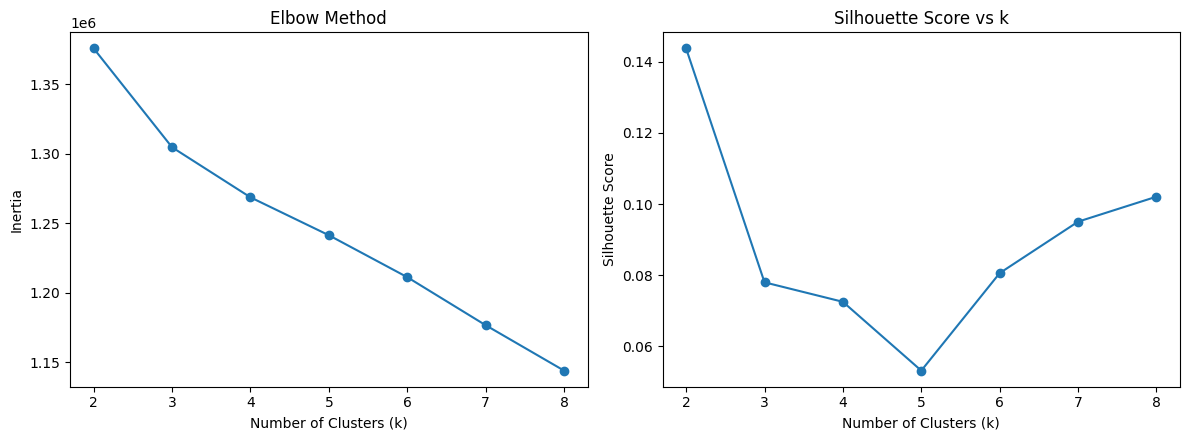

In [9]:
fig, (ax1, ax2) = plt.subplots(
    1,
    2,
    figsize=(12, 4.5)
)

# Elbow plot
ax1.plot(
    list(k_range),
    inertias,
    marker="o"
)

ax1.set_title("Elbow Method")
ax1.set_xlabel("Number of Clusters (k)")
ax1.set_ylabel("Inertia")


# Silhouette plot
ax2.plot(
    list(k_range),
    sil_scores,
    marker="o"
)

ax2.set_title("Silhouette Score vs k")
ax2.set_xlabel("Number of Clusters (k)")
ax2.set_ylabel("Silhouette Score")

plt.tight_layout()
plt.show()

In [10]:
best_k = list(k_range)[
    int(np.argmax(sil_scores))
]

print("Silhouette-suggested K =", best_k)

print("\nSilhouette scores:")

for k, score in zip(k_range, sil_scores):
    print(
        f"k={k}: {score:.3f}"
    )

Silhouette-suggested K = 2

Silhouette scores:
k=2: 0.144
k=3: 0.078
k=4: 0.073
k=5: 0.053
k=6: 0.081
k=7: 0.095
k=8: 0.102


In [11]:
kmeans = KMeans(
    n_clusters=best_k,
    n_init=10,
    random_state=RANDOM_STATE
)

km_labels = kmeans.fit_predict(X)

sil = silhouette_score(
    X[sil_sample_idx],
    km_labels[sil_sample_idx]
)

print("=" * 50)
print("K-MEANS RESULTS")
print("=" * 50)

print("K =", best_k)
print("Silhouette Score =", round(sil, 3))

print("\nCluster sizes:")

print(
    pd.Series(km_labels)
    .value_counts()
    .sort_index()
)

K-MEANS RESULTS
K = 2
Silhouette Score = 0.144

Cluster sizes:
0    26429
1    23571
Name: count, dtype: int64


In [12]:
profiled = feature_df.copy()

profiled["KMeansCluster"] = km_labels

profiled["PlacementStatus"] = df[
    "PlacementStatus"
].values

summary = profiled.groupby(
    "KMeansCluster"
).agg(
    n_students=("PlacementStatus", "size"),

    placement_rate=("PlacementStatus", "mean"),

    avg_CGPA=("CGPA", "mean"),

    avg_AttendancePercent=(
        "AttendancePercent",
        "mean"
    ),

    avg_AptitudeTestScore=(
        "AptitudeTestScore",
        "mean"
    ),

    avg_SoftSkillsRating=(
        "SoftSkillsRating",
        "mean"
    ),

    avg_CodingTestScore=(
        "CodingTestScore",
        "mean"
    ),

    avg_MockInterviewScore=(
        "MockInterviewScore",
        "mean"
    ),

    avg_Internships=(
        "Internships",
        "mean"
    ),

    avg_Projects=(
        "Projects",
        "mean"
    )

).round(3)

print("\n--- Cluster Profiles ---")

display(summary)


--- Cluster Profiles ---


,n_students,placement_rate,avg_CGPA,avg_AttendancePercent,avg_AptitudeTestScore,avg_SoftSkillsRating,avg_CodingTestScore,avg_MockInterviewScore,avg_Internships,avg_Projects
KMeansCluster,,,,,,,,,,
0,26429,0.202,6.558,67.338,54.559,5.444,47.260,54.743,0.621,1.556
1,23571,0.781,8.131,83.340,76.411,7.658,74.035,76.239,1.978,3.628


In [13]:
summary.to_csv(
    "/content/drive/MyDrive/colab/cluster_profiles.csv"
)

print(
    "Saved -> cluster_profiles.csv"
)

Saved -> cluster_profiles.csv


In [14]:
sub_idx = np.random.RandomState(
    RANDOM_STATE
).choice(
    len(X),
    5000,
    replace=False
)

X_sub = X[sub_idx]

hc = AgglomerativeClustering(
    n_clusters=best_k,
    linkage="ward"
)

hc_labels = hc.fit_predict(X_sub)

sil_hc = silhouette_score(
    X_sub,
    hc_labels
)

print(
    f"Hierarchical Clustering "
    f"(k={best_k}) silhouette: {sil_hc:.3f}"
)

Hierarchical Clustering (k=2) silhouette: 0.114


In [15]:
db = DBSCAN(
    eps=4.0,
    min_samples=15
)

db_labels = db.fit_predict(X_sub)

n_db_clusters = (
    len(set(db_labels))
    - (1 if -1 in db_labels else 0)
)

n_noise = int(
    np.sum(db_labels == -1)
)

print("=" * 50)
print("DBSCAN RESULTS")
print("=" * 50)

print("Number of clusters:", n_db_clusters)
print("Number of noise points:", n_noise)

if n_db_clusters >= 2:

    mask = db_labels != -1

    db_silhouette = silhouette_score(
        X_sub[mask],
        db_labels[mask]
    )

    print(
        "DBSCAN silhouette:",
        round(db_silhouette, 3)
    )

DBSCAN RESULTS
Number of clusters: 6
Number of noise points: 2083
DBSCAN silhouette: -0.064


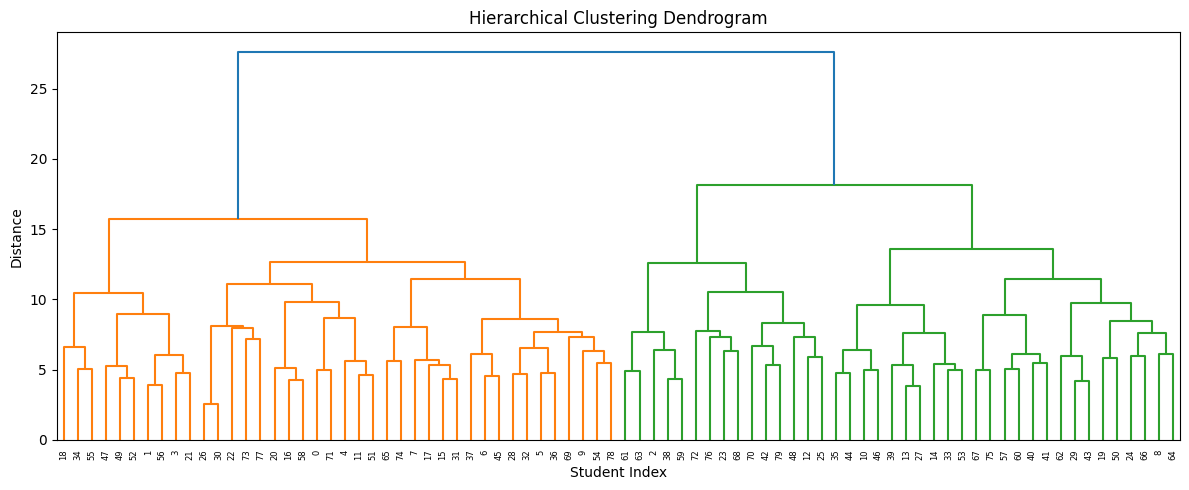

In [16]:
dendro_idx = np.random.choice(
    len(X_sub),
    size=min(80, len(X_sub)),
    replace=False
)

Z = linkage(
    X_sub[dendro_idx],
    method="ward"
)

plt.figure(
    figsize=(12, 5)
)

dendrogram(Z)

plt.title(
    "Hierarchical Clustering Dendrogram"
)

plt.xlabel("Student Index")
plt.ylabel("Distance")

plt.tight_layout()
plt.show()

In [17]:
pca = PCA(
    n_components=2,
    random_state=RANDOM_STATE
)

X_pca_full = pca.fit_transform(X)

print("PCA completed!")
print("Original dimensions:", X.shape[1])
print("PCA dimensions:", X_pca_full.shape[1])

print(
    "Explained variance ratio:",
    pca.explained_variance_ratio_
)

print(
    "Total explained variance:",
    round(
        pca.explained_variance_ratio_.sum(),
        4
    )
)

PCA completed!
Original dimensions: 33
PCA dimensions: 2
Explained variance ratio: [0.2525452  0.04971866]
Total explained variance: 0.3023


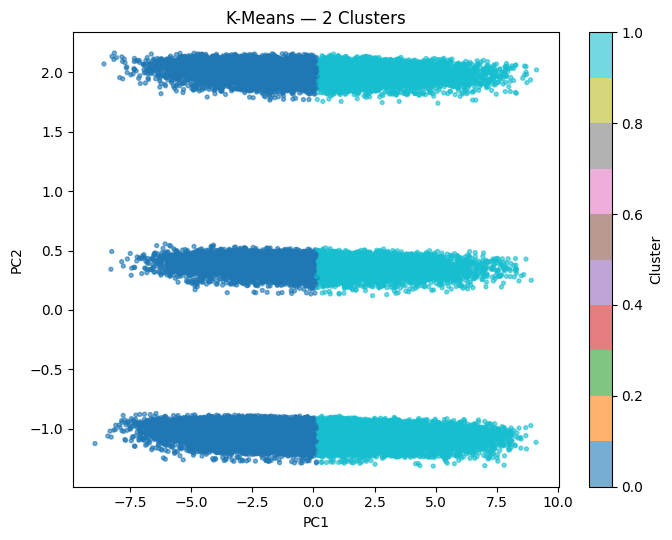

In [18]:
plt.figure(
    figsize=(7, 5.5)
)

plt.scatter(
    X_pca_full[:, 0],
    X_pca_full[:, 1],
    c=km_labels,
    cmap="tab10",
    s=8,
    alpha=0.6
)

plt.title(
    f"K-Means — {best_k} Clusters"
)

plt.xlabel("PC1")
plt.ylabel("PC2")

plt.colorbar(
    label="Cluster"
)

plt.tight_layout()
plt.show()

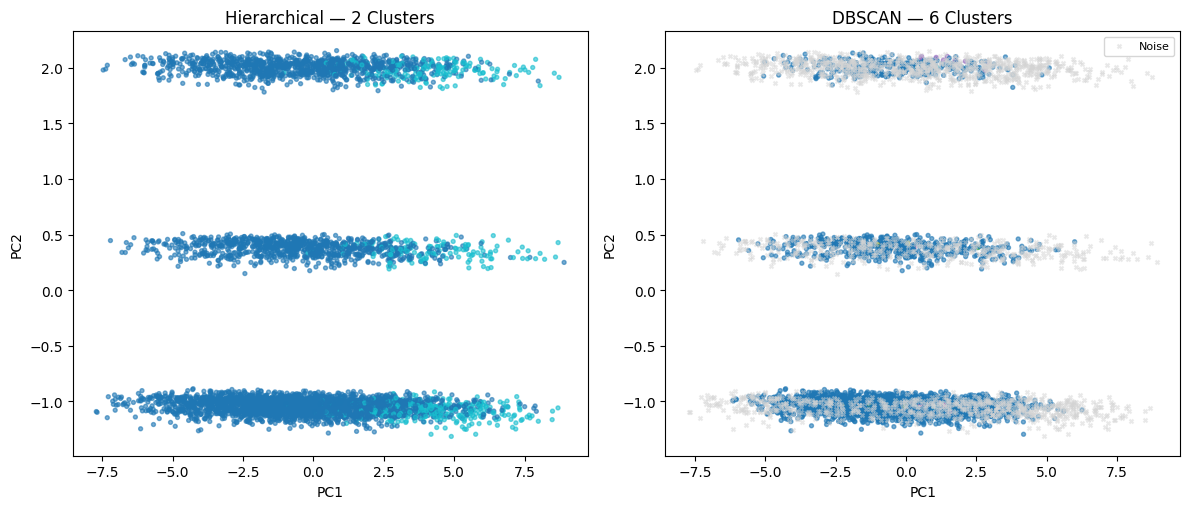

In [19]:
coords_sub = X_pca_full[sub_idx]

fig, axes = plt.subplots(
    1,
    2,
    figsize=(12, 5.2)
)

# Hierarchical clustering
axes[0].scatter(
    coords_sub[:, 0],
    coords_sub[:, 1],
    c=hc_labels,
    cmap="tab10",
    s=8,
    alpha=0.6
)

axes[0].set_title(
    f"Hierarchical — {best_k} Clusters"
)

axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")


# DBSCAN
noise_mask = db_labels == -1

axes[1].scatter(
    coords_sub[~noise_mask, 0],
    coords_sub[~noise_mask, 1],
    c=db_labels[~noise_mask],
    cmap="tab10",
    s=8,
    alpha=0.6
)

axes[1].scatter(
    coords_sub[noise_mask, 0],
    coords_sub[noise_mask, 1],
    c="lightgray",
    s=8,
    alpha=0.5,
    marker="x",
    label="Noise"
)

axes[1].legend(
    loc="upper right",
    fontsize=8
)

axes[1].set_title(
    f"DBSCAN — {n_db_clusters} Clusters"
)

axes[1].set_xlabel("PC1")
axes[1].set_ylabel("PC2")

plt.tight_layout()
plt.show()

In [20]:
df_out = df.copy()

df_out["KMeansCluster"] = km_labels

print("Cluster column added!")

df_out.head()

Cluster column added!


,Gender,City,CollegeTier,Stream,Specialisation,Hostel,HistoryOfBacklogs,CGPA,AttendancePercent,Internships,...,Certifications,Publications,AptitudeTestScore,SoftSkillsRating,CodingTestScore,MockInterviewScore,ExtraCurricular,PlacementStatus,IsAnomaly,KMeansCluster
0,Female,Delhi,Tier3,IT,DataScience,Yes,Yes,6.63,68.3,2,...,1,0,62.3,6.57,40.6,65.7,No,0,0,0
1,Male,Chennai,Tier2,ECE,AI,Yes,No,6.40,71.0,1,...,2,0,44.0,5.86,40.3,51.8,No,0,0,0
2,Female,Hyderabad,Tier3,ECE,Networking,No,No,7.73,75.1,1,...,2,1,73.8,7.50,73.6,67.9,No,1,0,1
3,Female,Jaipur,Tier3,ECE,Embedded,No,No,9.73,99.2,4,...,6,2,100.0,9.41,98.7,NaN,No,1,0,1
4,Male,Ahmedabad,Tier3,Mechanical,DataScience,No,No,9.01,99.6,2,...,4,2,90.8,9.24,83.1,100.0,No,1,0,1


In [21]:
output_path = (
    "/content/drive/MyDrive/colab/"
    "placement_predict_with_clusters.csv"
)

df_out.to_csv(
    output_path,
    index=False
)

print(
    "Saved deliverable ->",
    output_path
)

Saved deliverable -> /content/drive/MyDrive/colab/placement_predict_with_clusters.csv


In [22]:
import os

folder = "/content/drive/MyDrive/colab"

print("Output files:")

for file in os.listdir(folder):

    if file.endswith(".csv"):

        print("✓", file)

Output files:
✓ placement_dataset.csv
✓ placement_predict_50k.csv
✓ age_insurance.csv
✓ placement_predict_50k Dataset (1).csv
✓ simple_placement_dataset.csv
✓ placement_predict_50k_adjusted.csv
✓ cluster_profiles.csv
✓ placement_predict_with_clusters.csv
